# Display Query Image and Retrieval Results

In this notebook, we will:

- Allow the user to input a row number from the evaluation results.
- Display the corresponding query image and its top retrieval results for manual inspection.
- Highlight correct and incorrect matches.
  
---

## **Step 1: Import Libraries**


We begin by importing the necessary libraries.

In [2]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os
import gc

---

## **Step 2: Load Data**

We load the embeddings, image files, and evaluation results.

In [3]:
# Load embeddings and data
embeddings = np.load('matches_embeddings.npy')
image_files = np.load('matches_image_files.npy', allow_pickle=True)
base_ids = np.load('matches_base_ids.npy', allow_pickle=True)

# Load evaluation results
df_results = pd.read_csv('evaluation_results.csv')

---

## **Step 3: Define Helper Functions**

We define functions to display images and retrieve similar images.

In [4]:
# Function to display an image
def display_image(image_file, title=''):
    img = Image.open(image_file)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

# Function to retrieve similar images
def retrieve_similar_images(query_embedding, embeddings, image_files, base_ids, query_base_id, k=5):
    similarities = np.dot(embeddings, query_embedding)
    similarities = similarities.flatten()
    indices = np.argsort(-similarities)
    retrieved_files = [image_files[idx] for idx in indices if similarities[idx] != -np.inf]
    retrieved_base_ids = [base_ids[idx] for idx in indices if similarities[idx] != -np.inf]
    retrieved_sims = [similarities[idx] for idx in indices if similarities[idx] != -np.inf]
    # Exclude the query image itself
    retrieved_files = retrieved_files[1:k+1]
    retrieved_base_ids = retrieved_base_ids[1:k+1]
    retrieved_sims = retrieved_sims[1:k+1]
    return retrieved_files, retrieved_base_ids, retrieved_sims

---

## **Step 4: Get User Input and Display Results**

We prompt the user to input a row number and display the corresponding images.

Enter the row number (0 to 50):  4


Query Image: 387_04.jpg


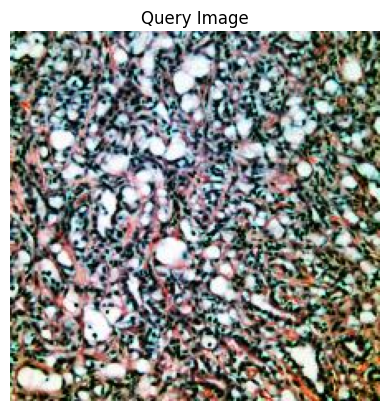

Retrieved Images:


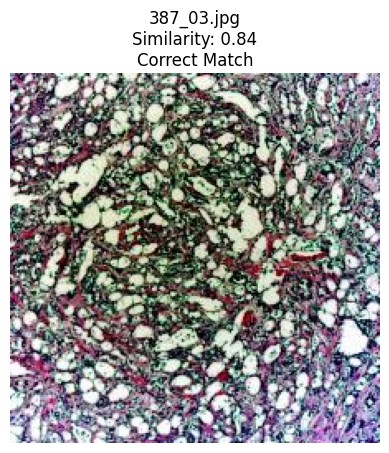

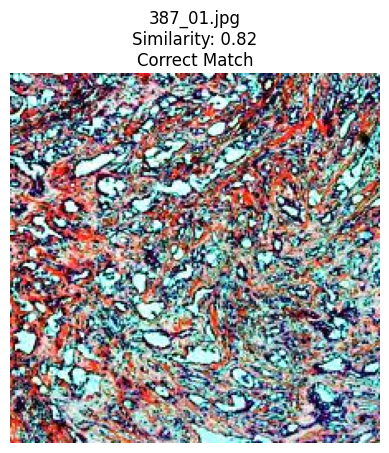

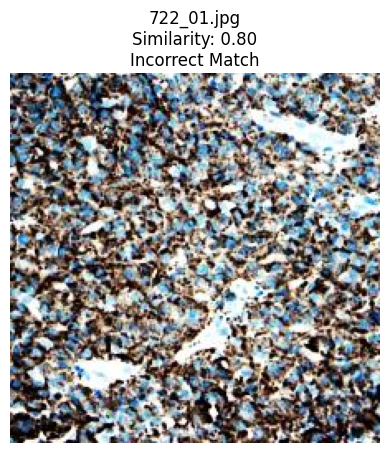

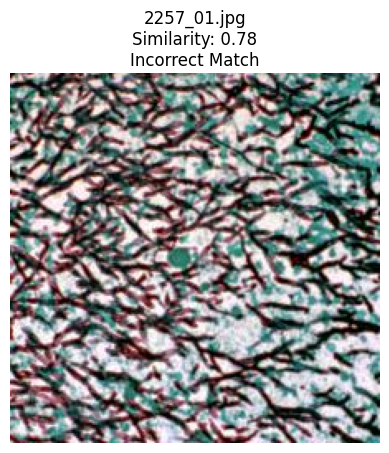

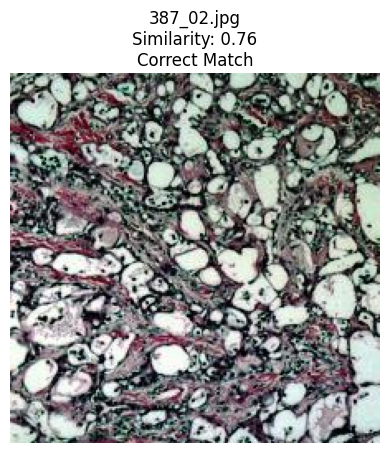

In [6]:
# Get user input
try:
    row_number = int(input(f'Enter the row number (0 to {len(df_results)-1}): '))
    if 0 <= row_number < len(df_results):
        query_image_file = df_results.loc[row_number, 'Query Image']
        query_idx = np.where(image_files == query_image_file)[0][0]
        query_embedding = embeddings[query_idx]
        query_base_id = base_ids[query_idx]

        # Display Query Image
        print(f'Query Image: {query_image_file}')
        display_image(os.path.join('./matches_preprocessed/', query_image_file), title='Query Image')

        # Retrieve and Display Similar Images
        k = 5  # Number of results to display
        retrieved_files, retrieved_base_ids, retrieved_sims = retrieve_similar_images(
            query_embedding, embeddings, image_files, base_ids, query_base_id, k)
        print('Retrieved Images:')
        for img_file, base_id, sim in zip(retrieved_files, retrieved_base_ids, retrieved_sims):
            correctness = 'Correct Match' if base_id == query_base_id else 'Incorrect Match'
            title = f'{img_file}\nSimilarity: {sim:.2f}\n{correctness}'
            display_image(os.path.join('./matches_preprocessed/', img_file), title=title)
    else:
        print('Invalid row number.')
except ValueError:
    print('Please enter a valid integer.')


---

## **Step 5: Clear Memory**

We clear variables and free up memory.

In [ ]:
# Clear variables and free memory
del embeddings, image_files, base_ids, df_results
gc.collect()

---

## **Step 6: Conclusion**

We have successfully displayed the query image and its top retrieval results, highlighting correct and incorrect matches.